# H1 — Aumento sostenido de las temperaturas

Analizamos si las temperaturas en Euskal Herria han aumentado de forma significativa entre 1940 y 2025, tanto en valores medios como en la frecuencia de días extremos.

## 1. Imports y carga de datos

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.variables import CIUDADES, crear_dirs
from scripts.funciones_variables import cargar_datos
from scripts.analisis import temperaturas, anomalia_termica
from scripts.graficos import graficos_temp, graficos_anomalia

crear_dirs()
cargar_datos()

📂 Cargando datos...
  ✅ bilbo: 31,412 filas
  ✅ donostia: 31,412 filas
  ✅ gasteiz: 31,412 filas
  ✅ iruna: 31,412 filas
  ✅ baiona: 31,412 filas
  ✅ arrasate: 31,412 filas
  ✅ maule: 31,412 filas



## 2. Días con temperatura máxima > 30°C

Contamos cuántos días al año supera cada ciudad los 30°C. Las barras se colorean en verde (≤8 días), naranja (9–13) y rojo (≥14). La media móvil de 10 años suaviza la variabilidad interanual.

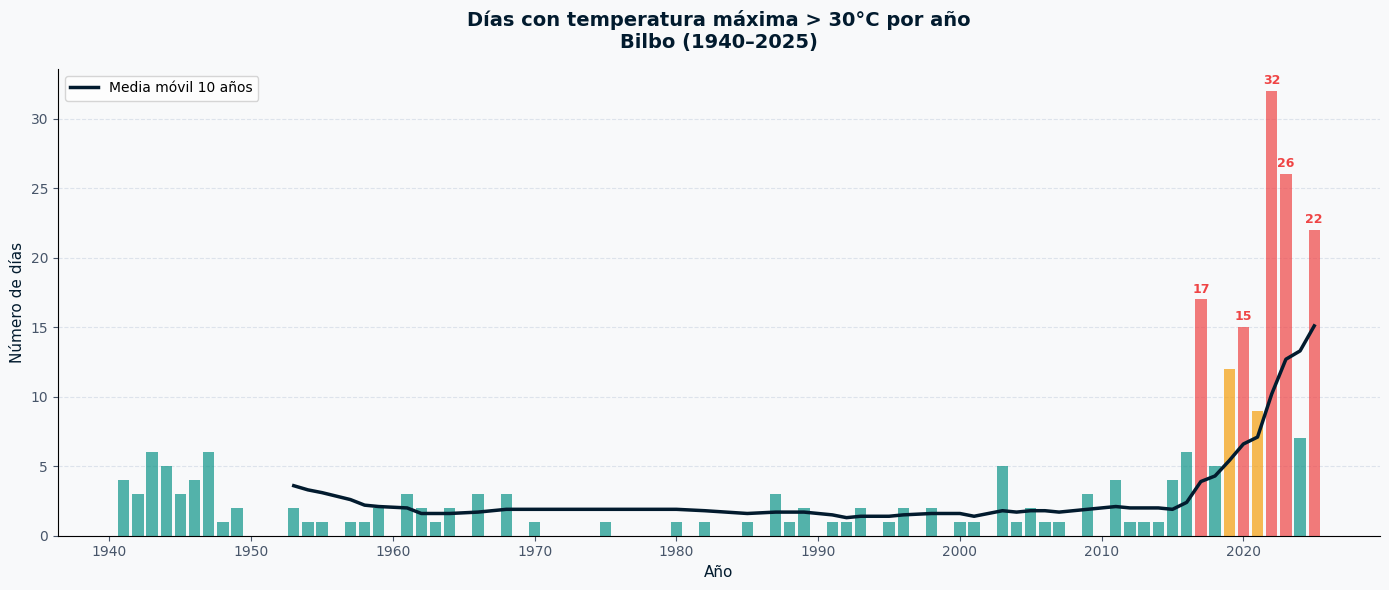

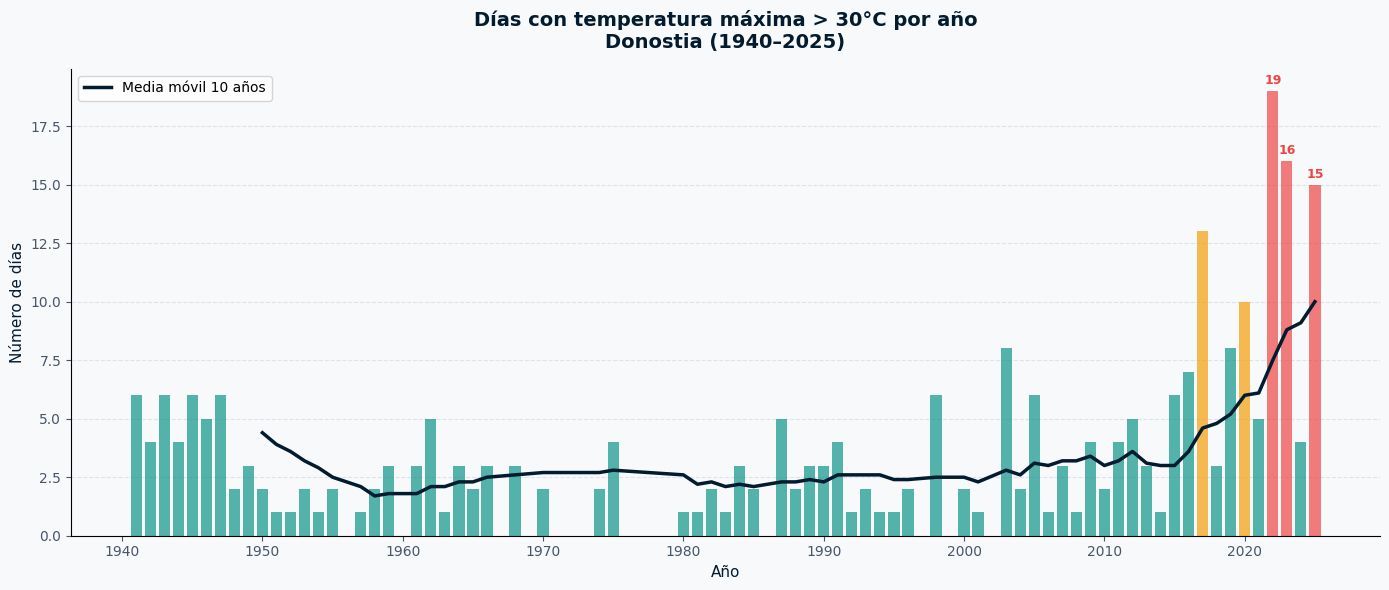

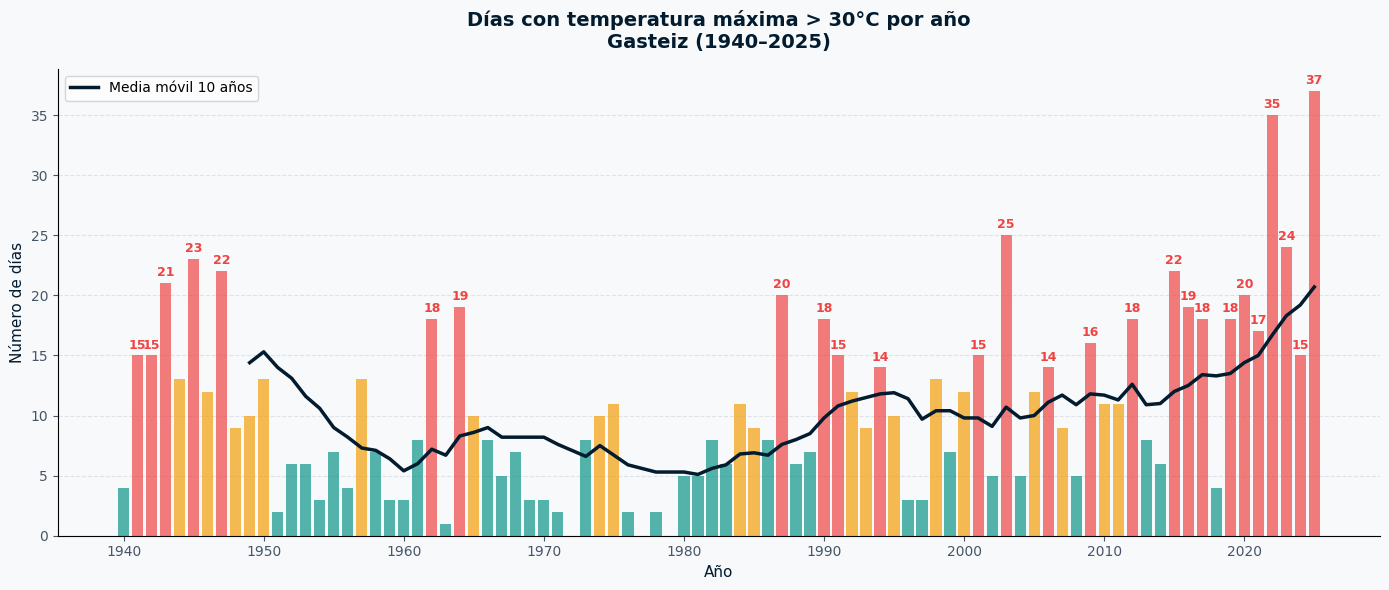

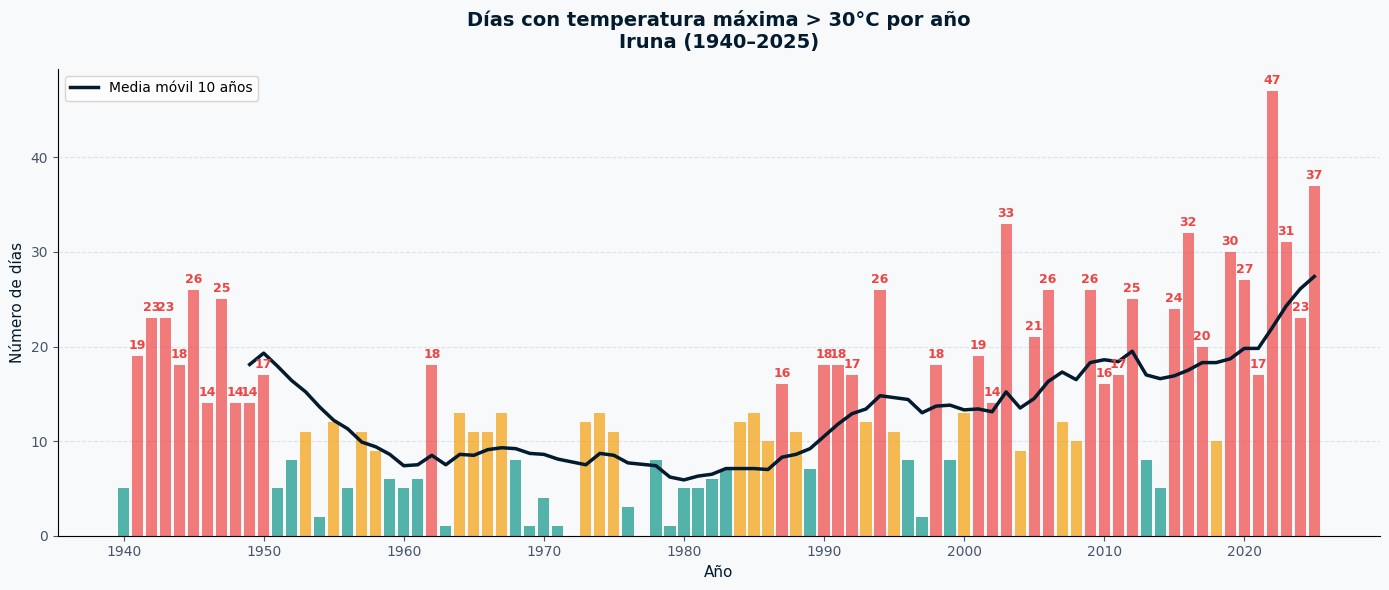

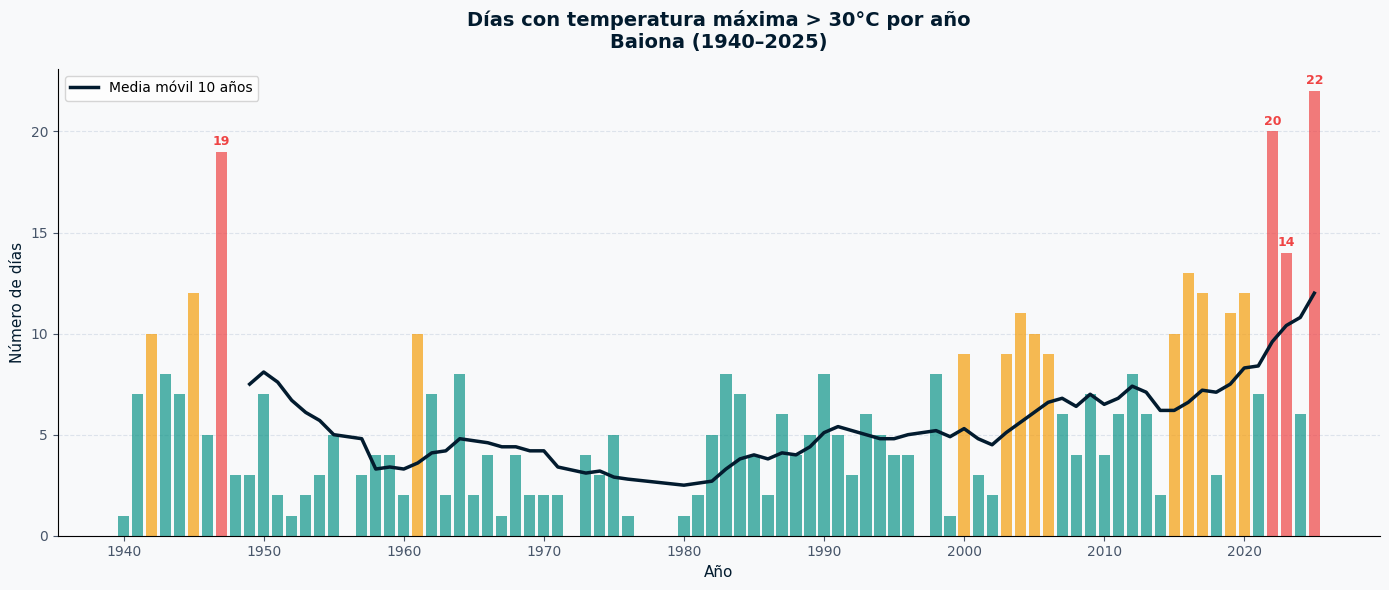

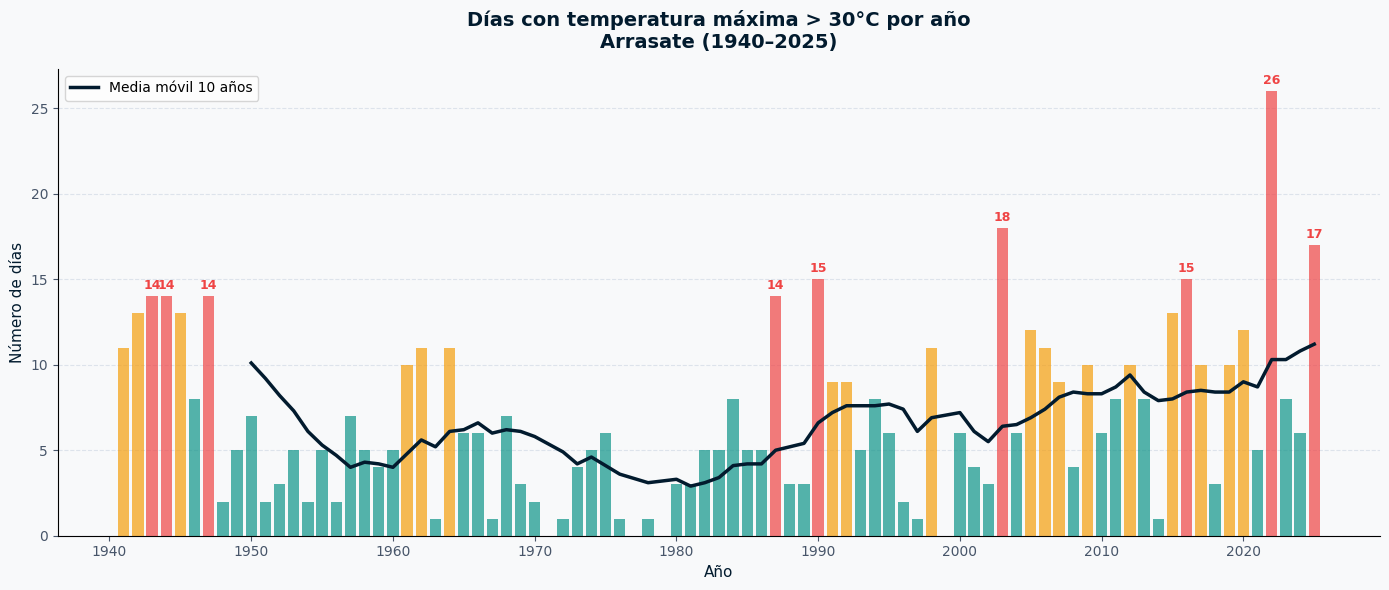

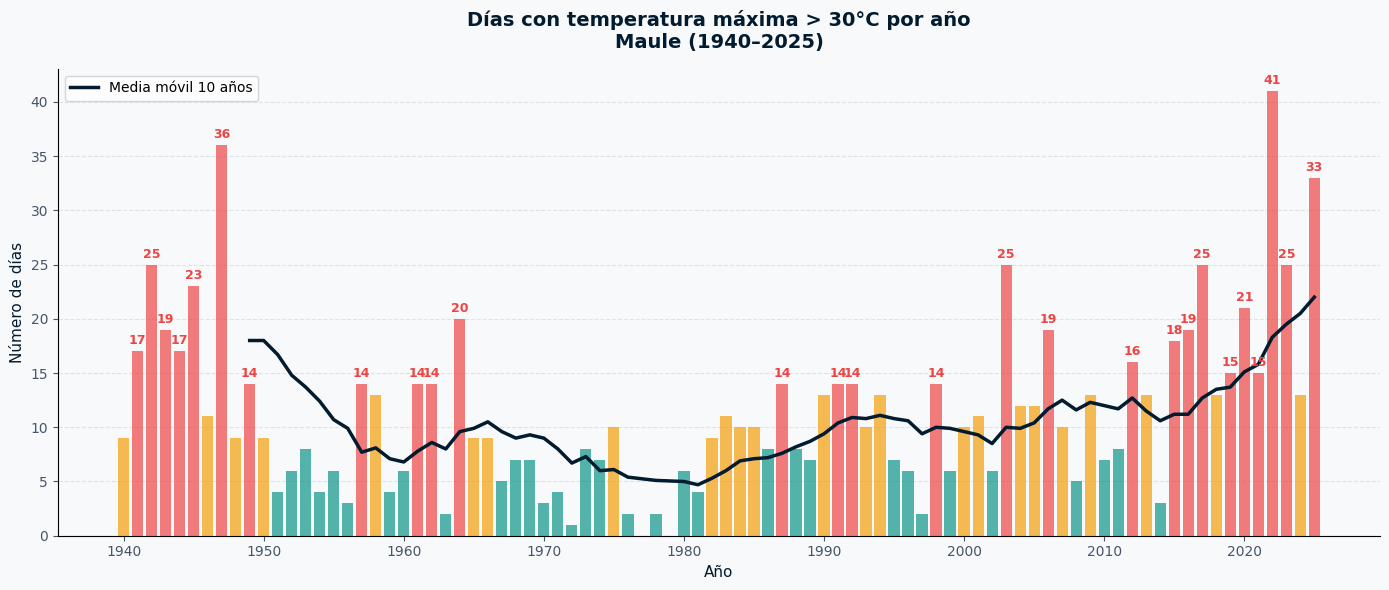

In [4]:
datos_temp = temperaturas.calcular_todos()
graficos_temp.graficar_dias_30(datos_temp['dias_30'])

## 3. Temperatura media anual con tendencia lineal

Calculamos la temperatura media anual de cada ciudad y ajustamos una regresión lineal para cuantificar el ritmo de calentamiento en °C/década.

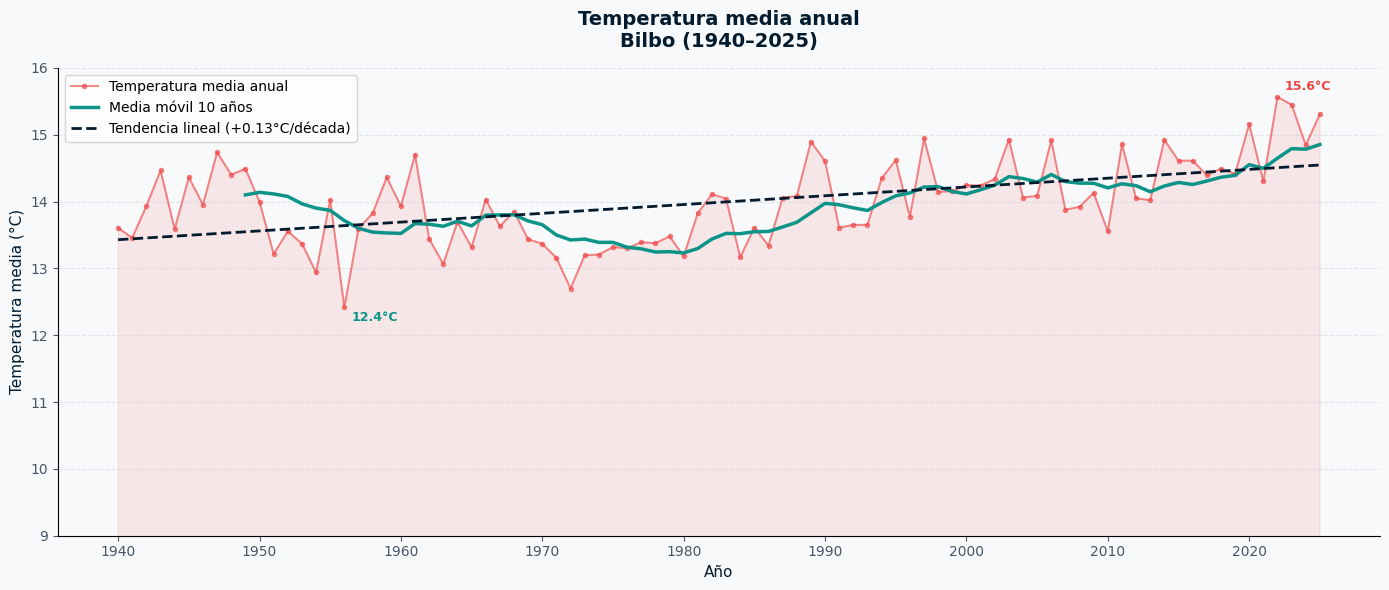

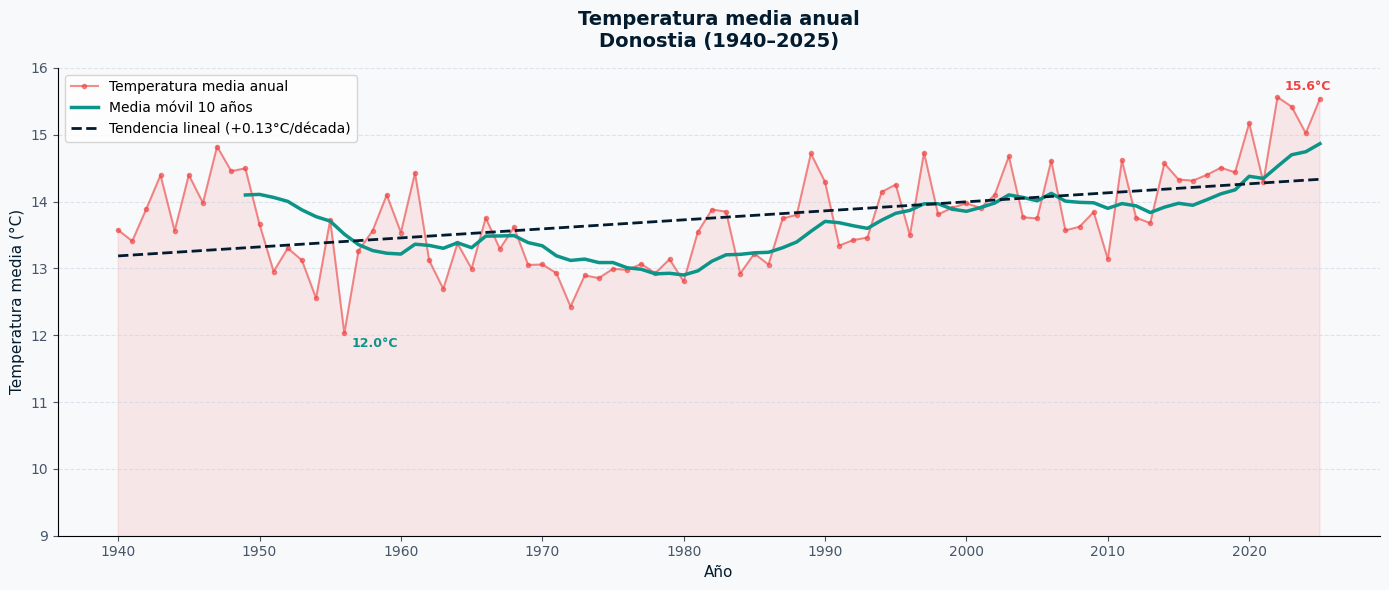

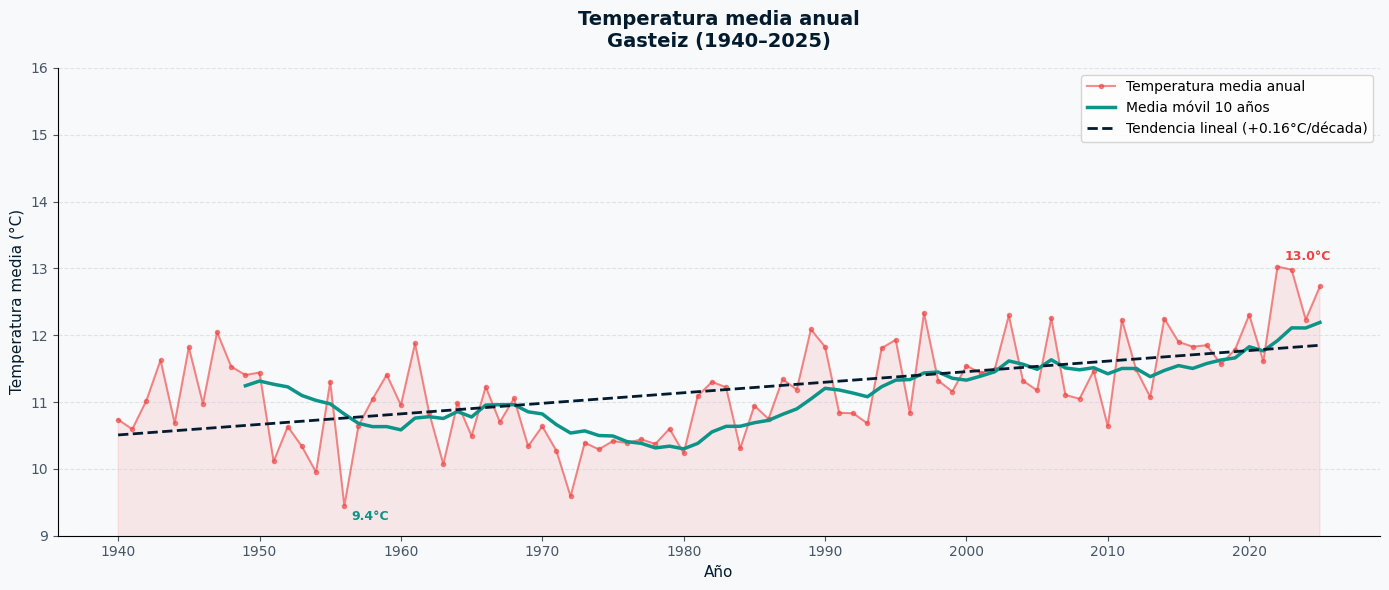

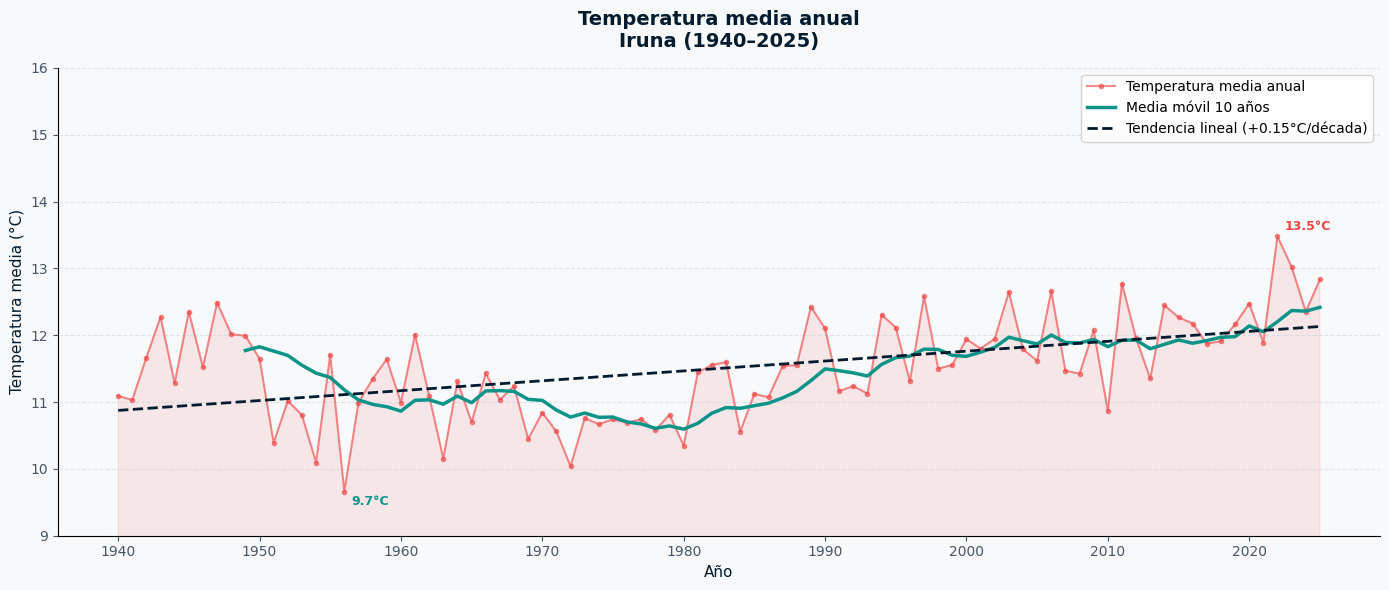

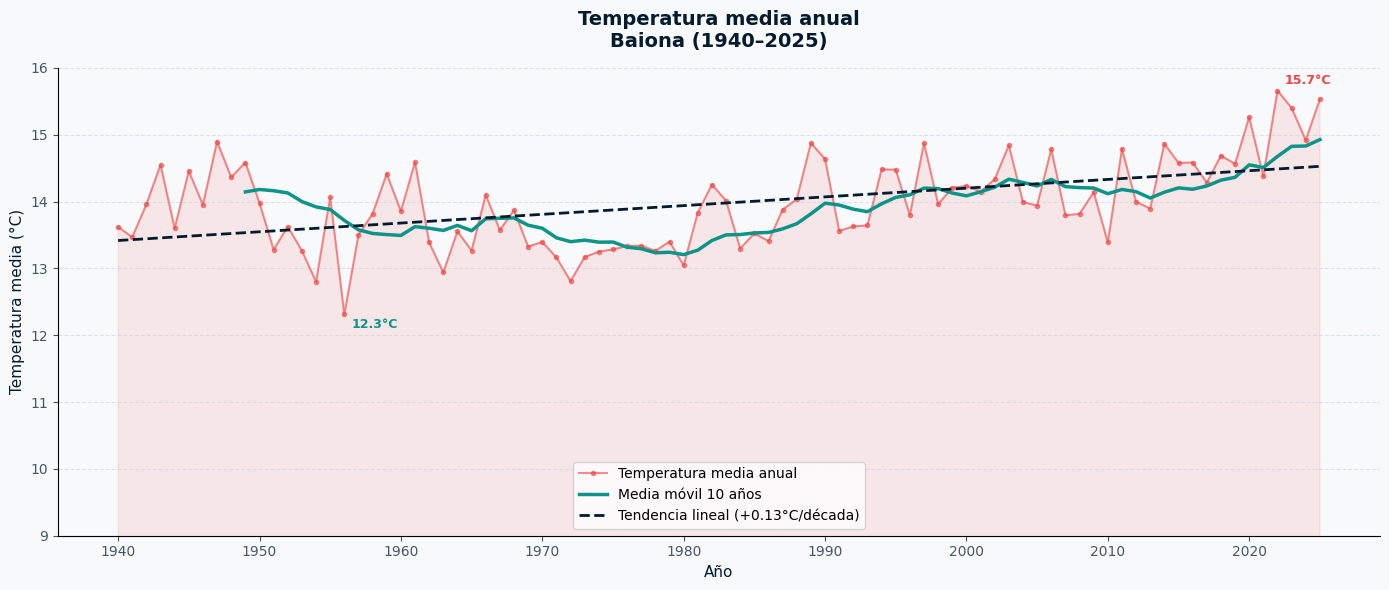

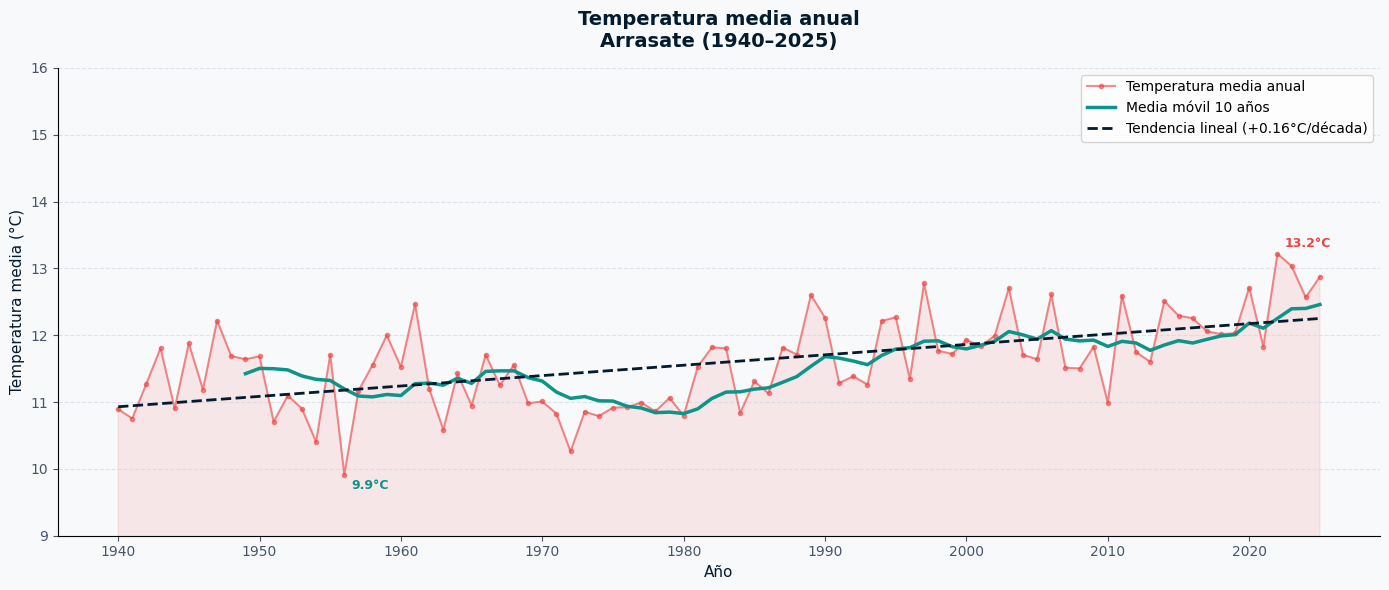

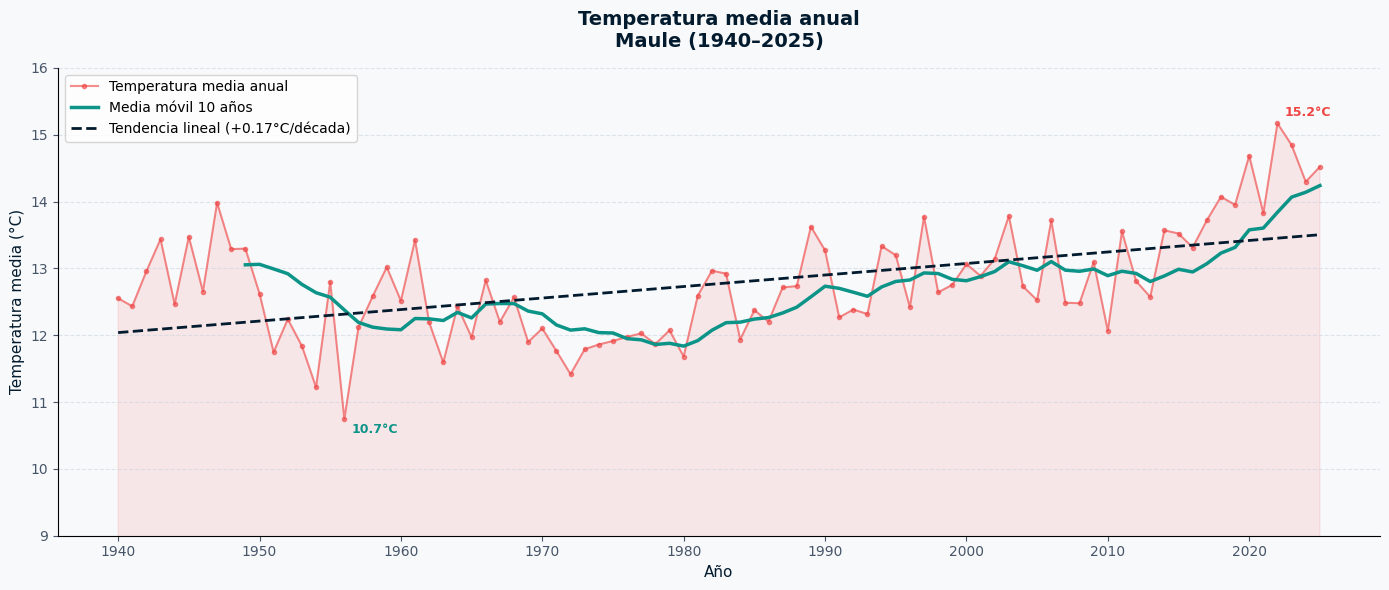

In [5]:
graficos_temp.graficar_temp_media_anual(datos_temp['temp_media'])

## 4. Heatmap de temperatura media mensual

Matriz año × mes que permite ver de un vistazo los meses y años más cálidos. Escala de color RdYlBu_r: azul = frío, rojo = caliente.

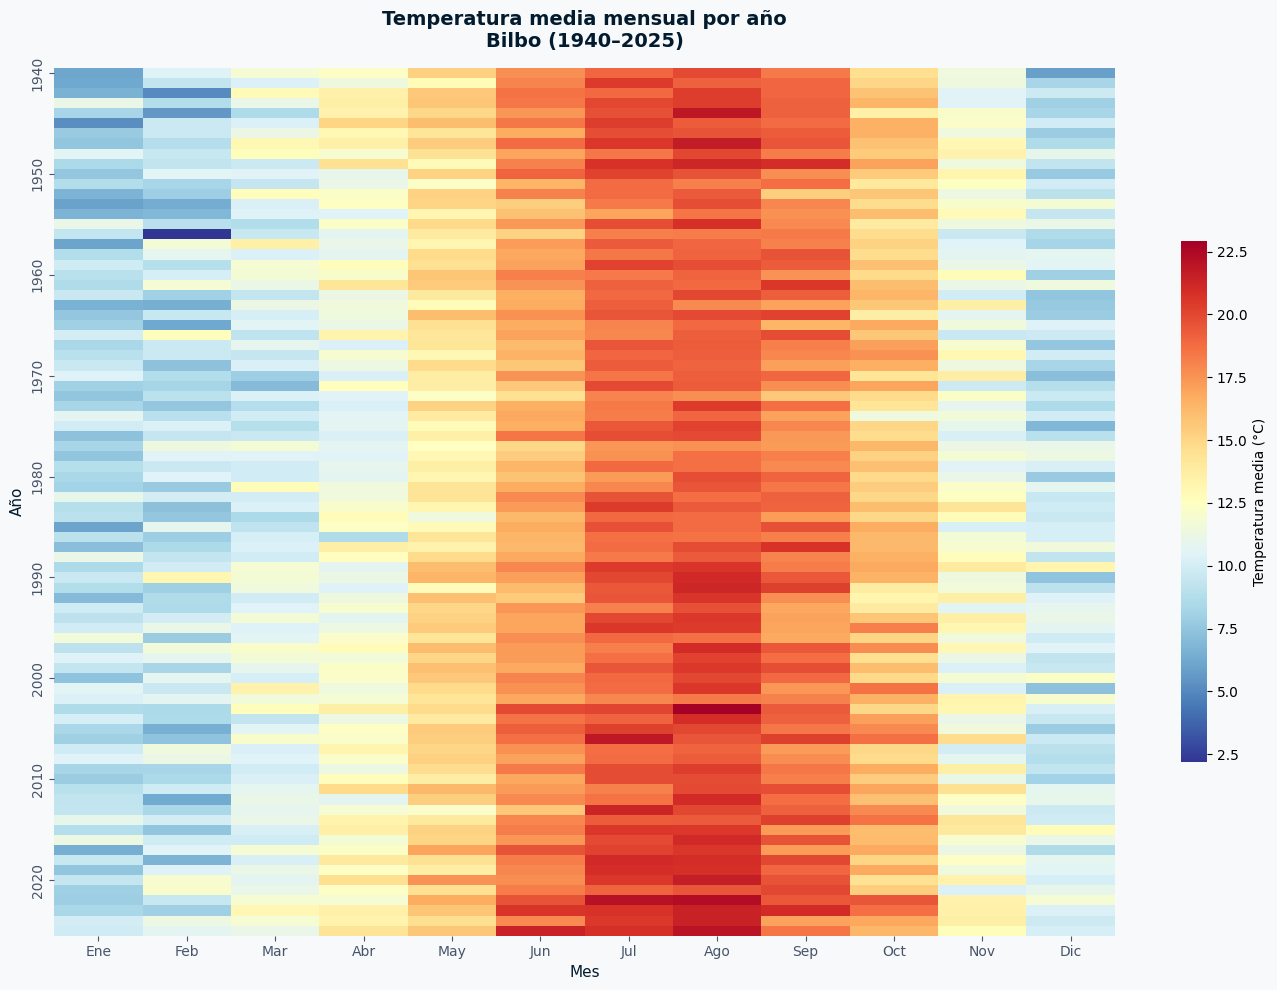

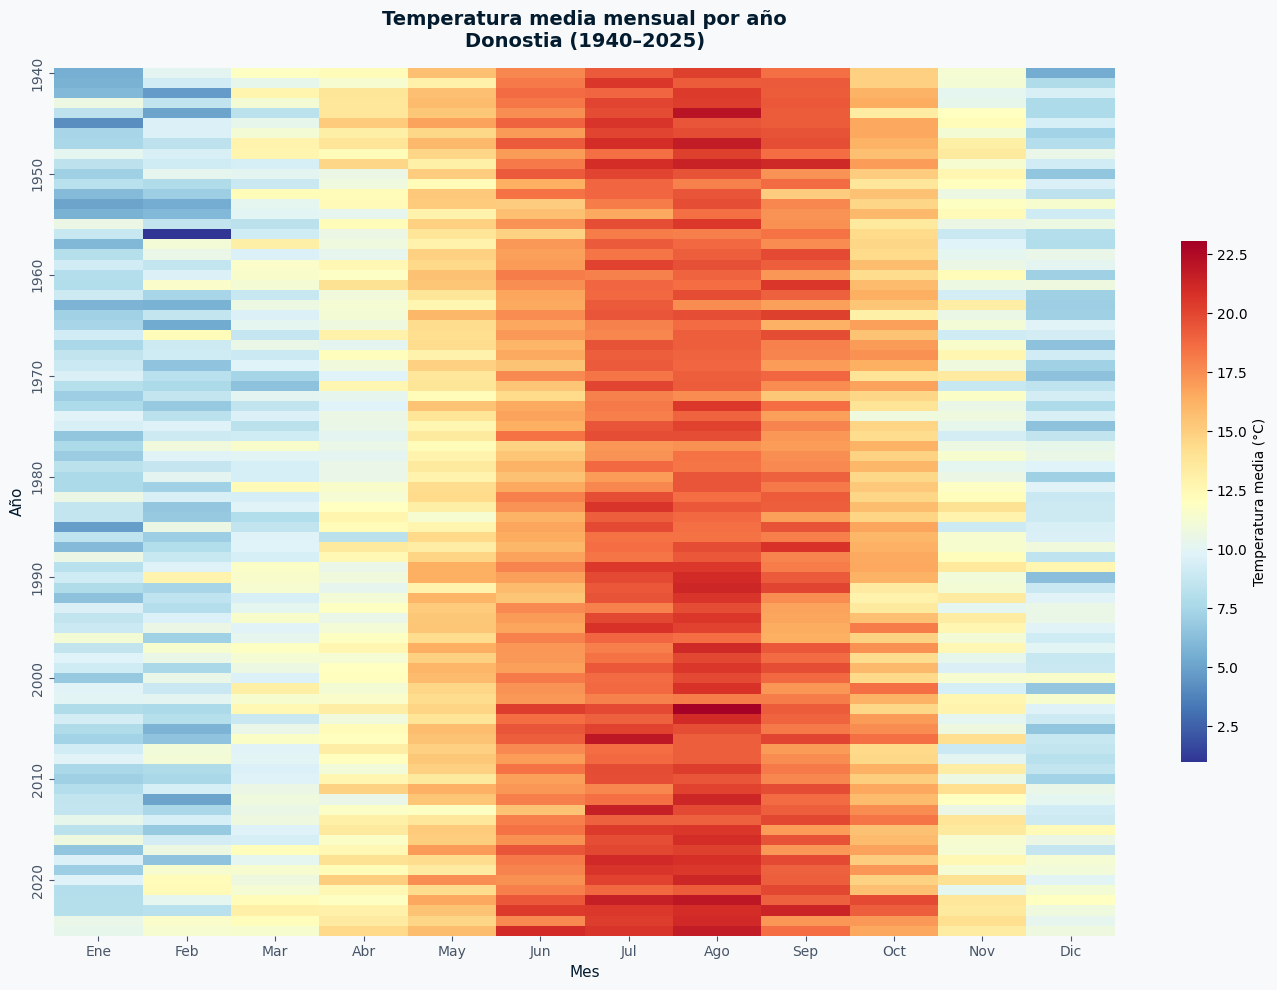

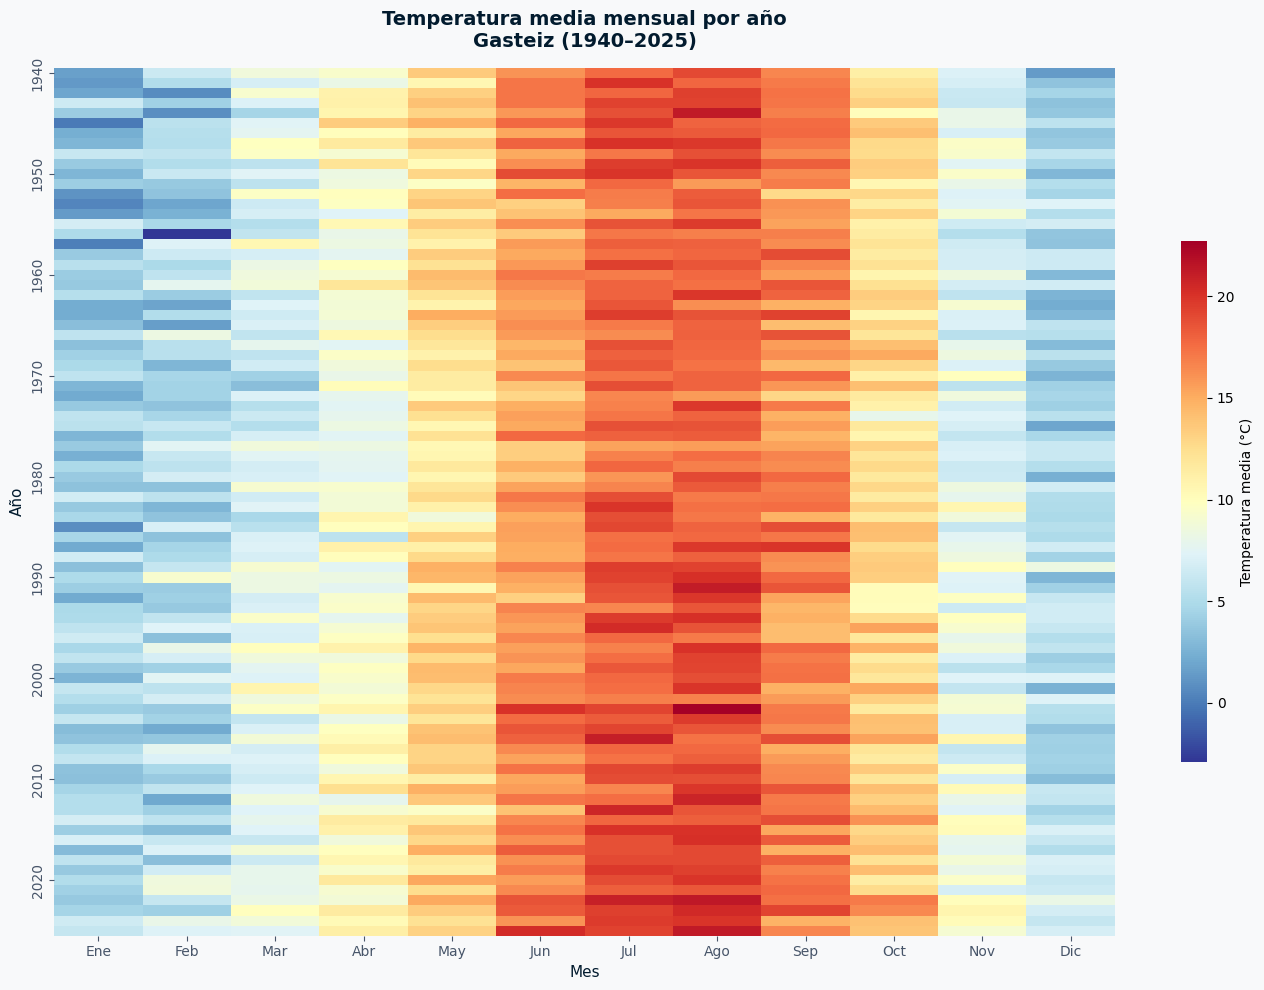

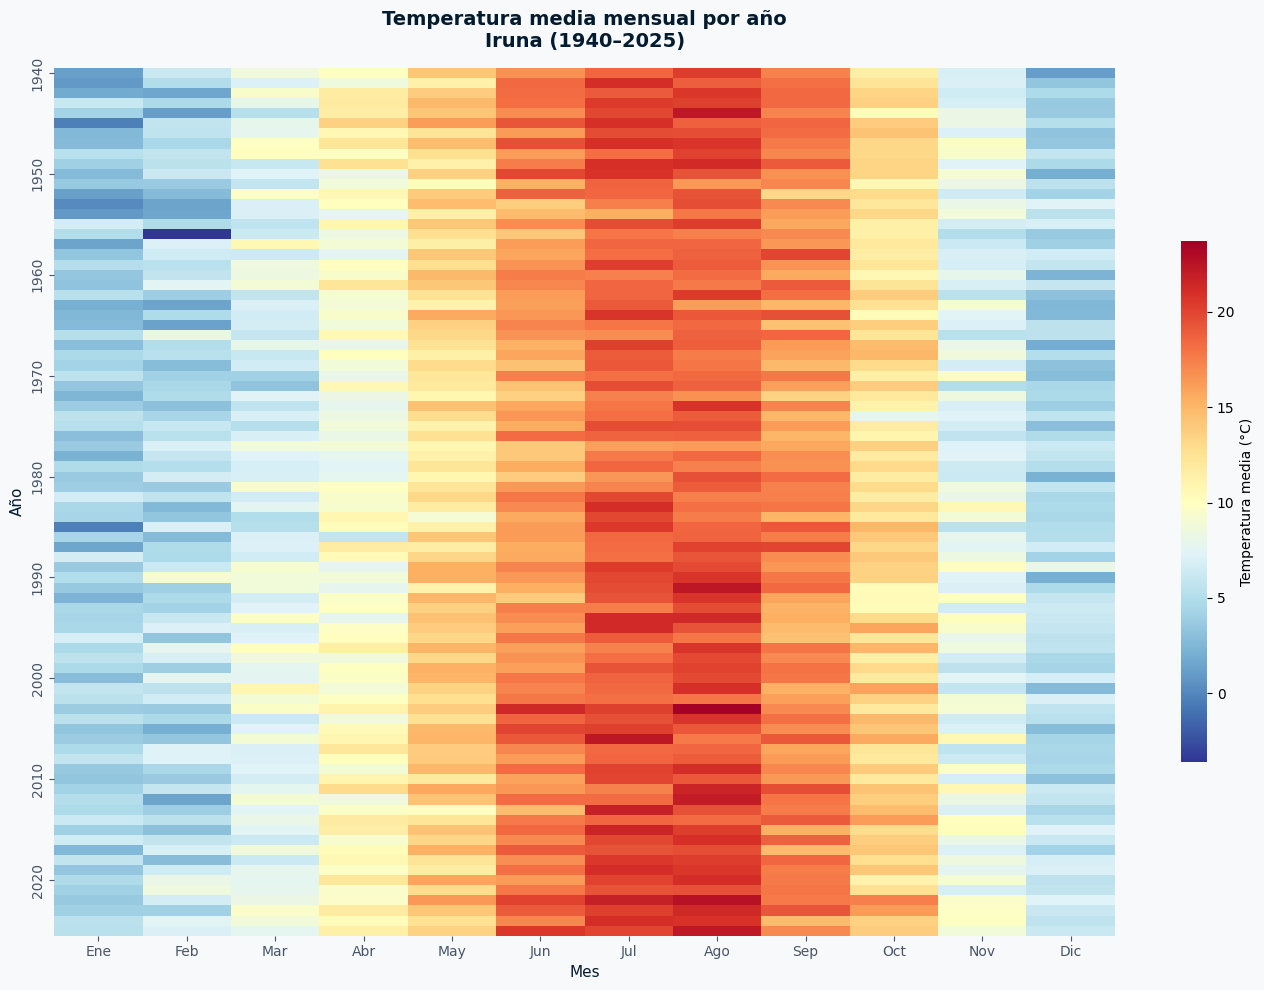

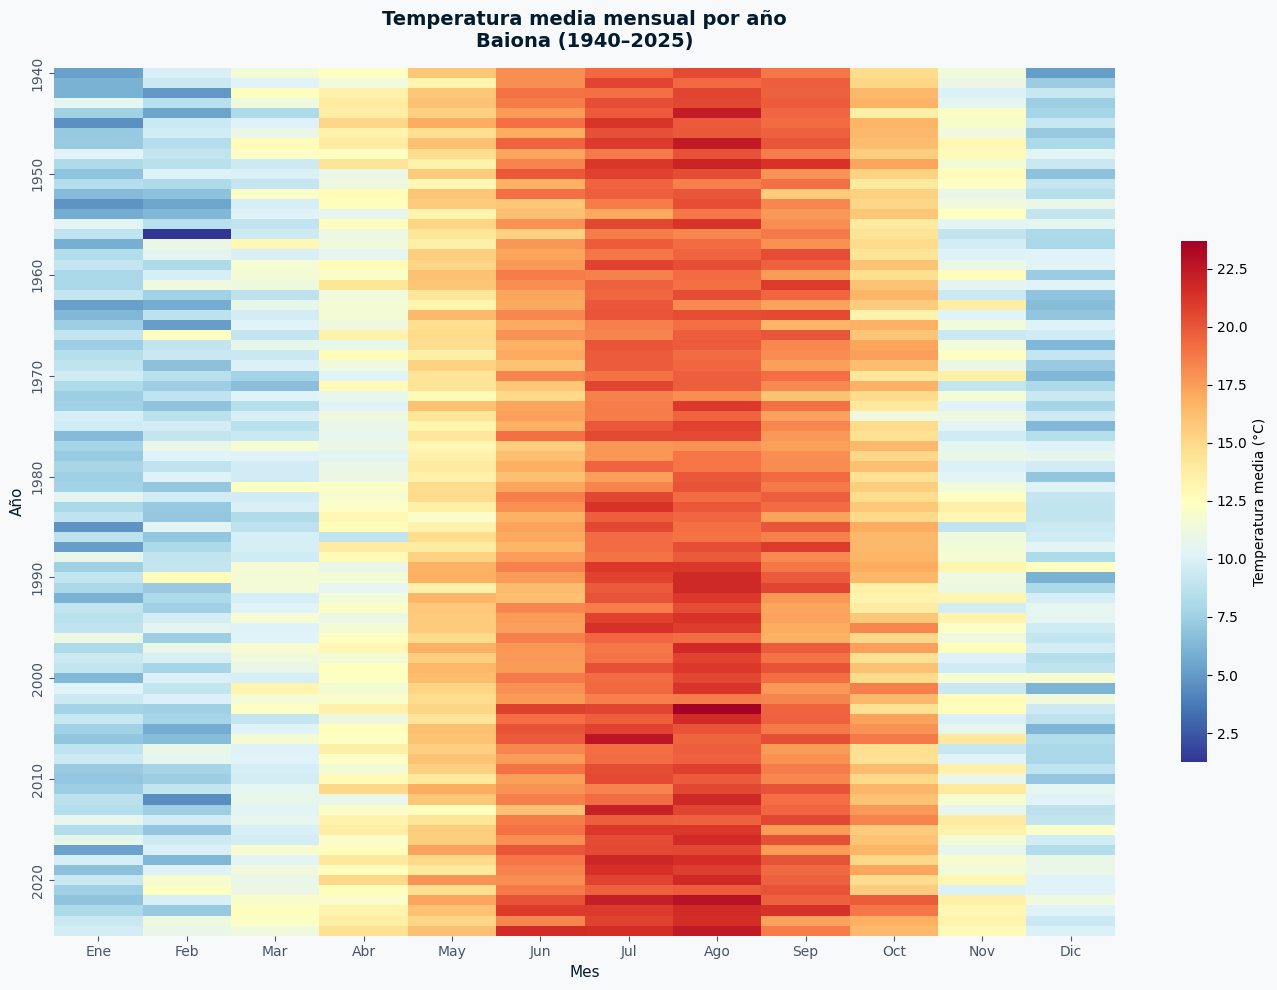

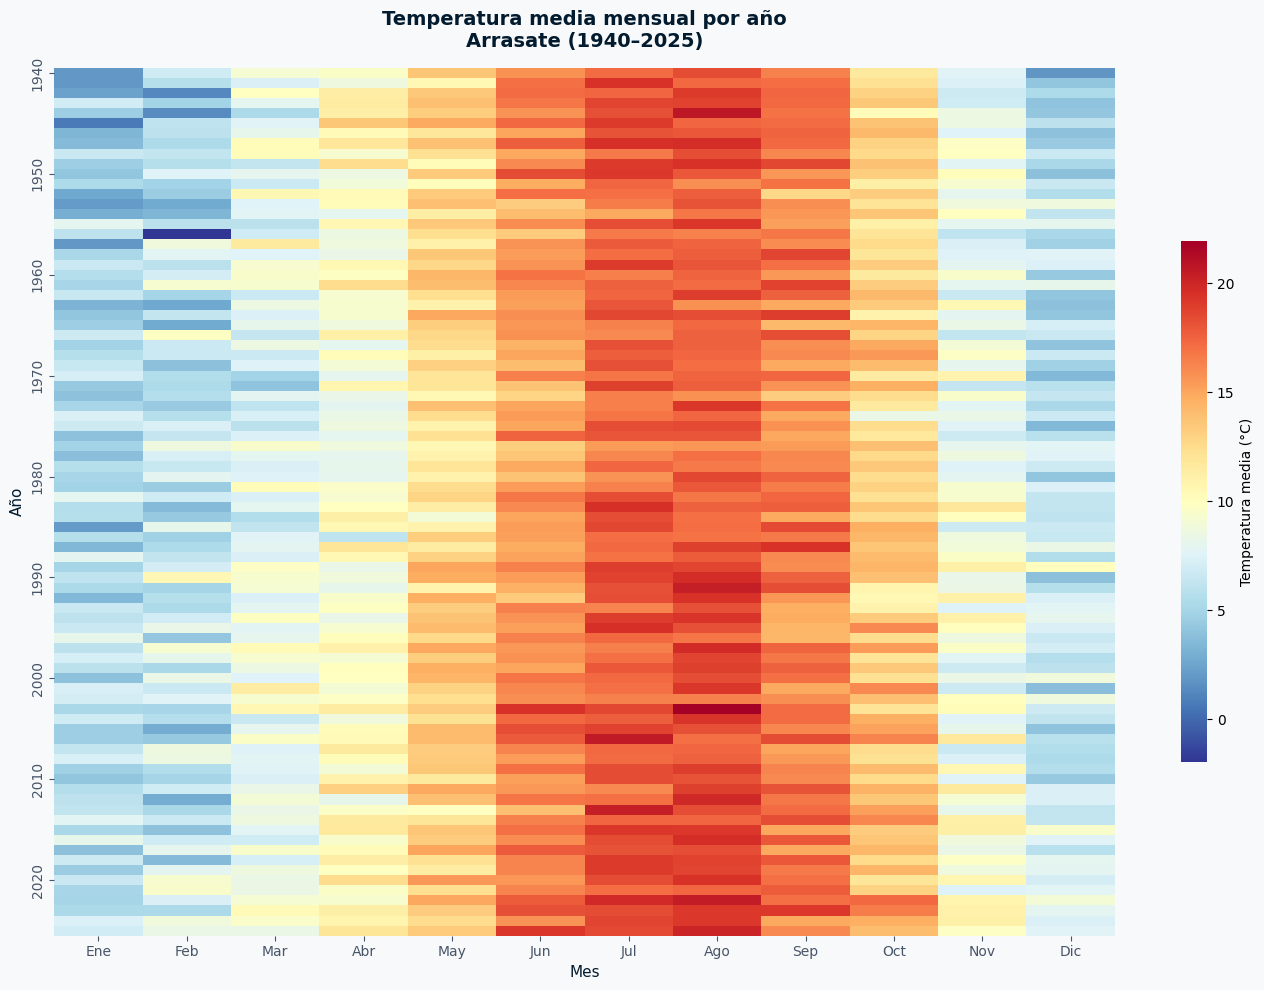

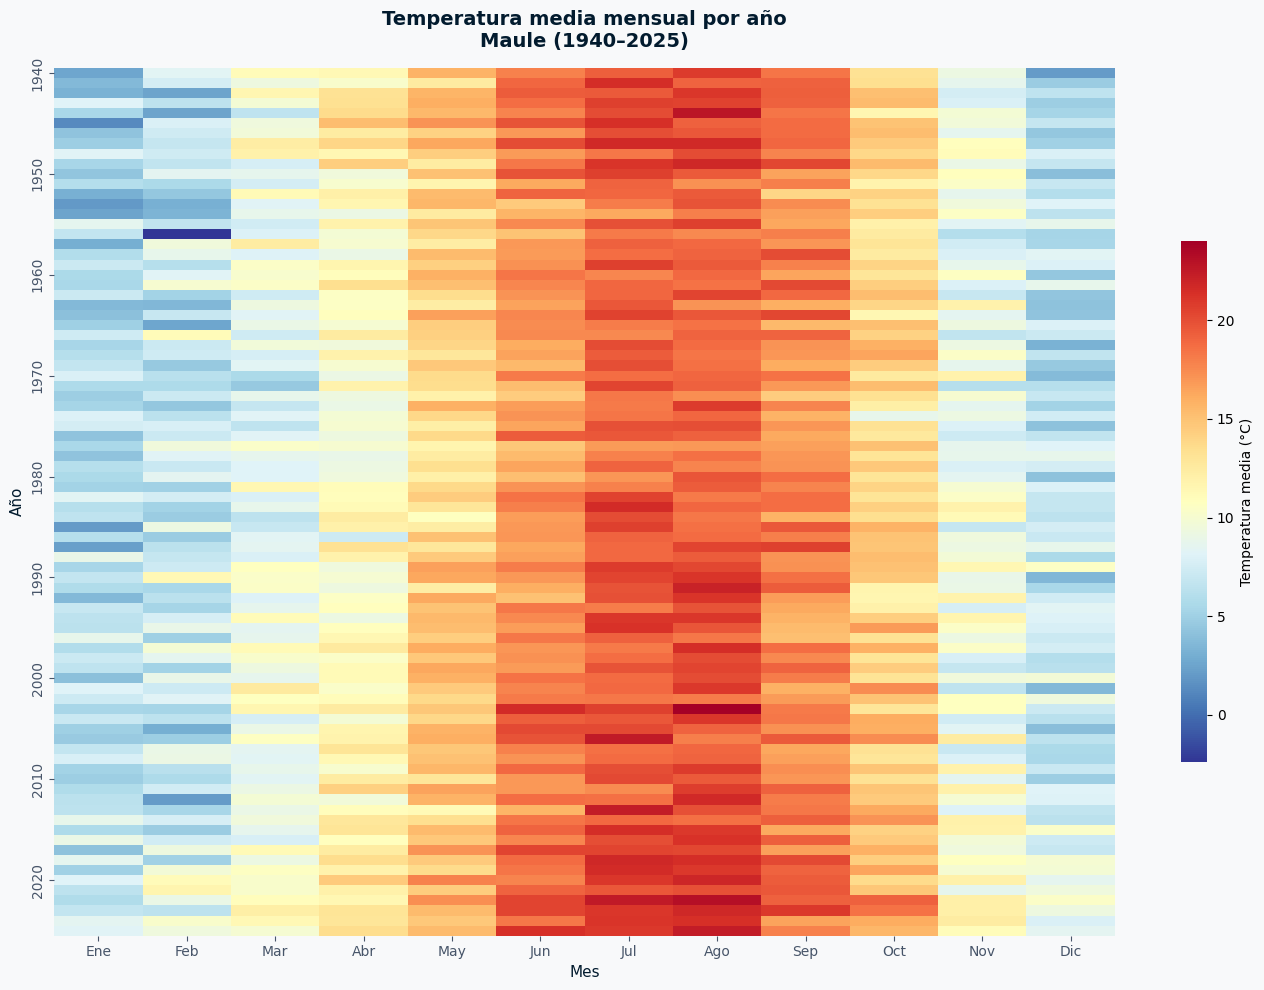

In [6]:
graficos_temp.graficar_heatmap_temp_mensual(CIUDADES)

## 5. Anomalía térmica anual (estándar OMM)

Calculamos la desviación de cada año respecto a la media del período base **1961–1990** (referencia estándar de la Organización Meteorológica Mundial). Barras rojas = años más cálidos que la media histórica. Barras azules = años más fríos.

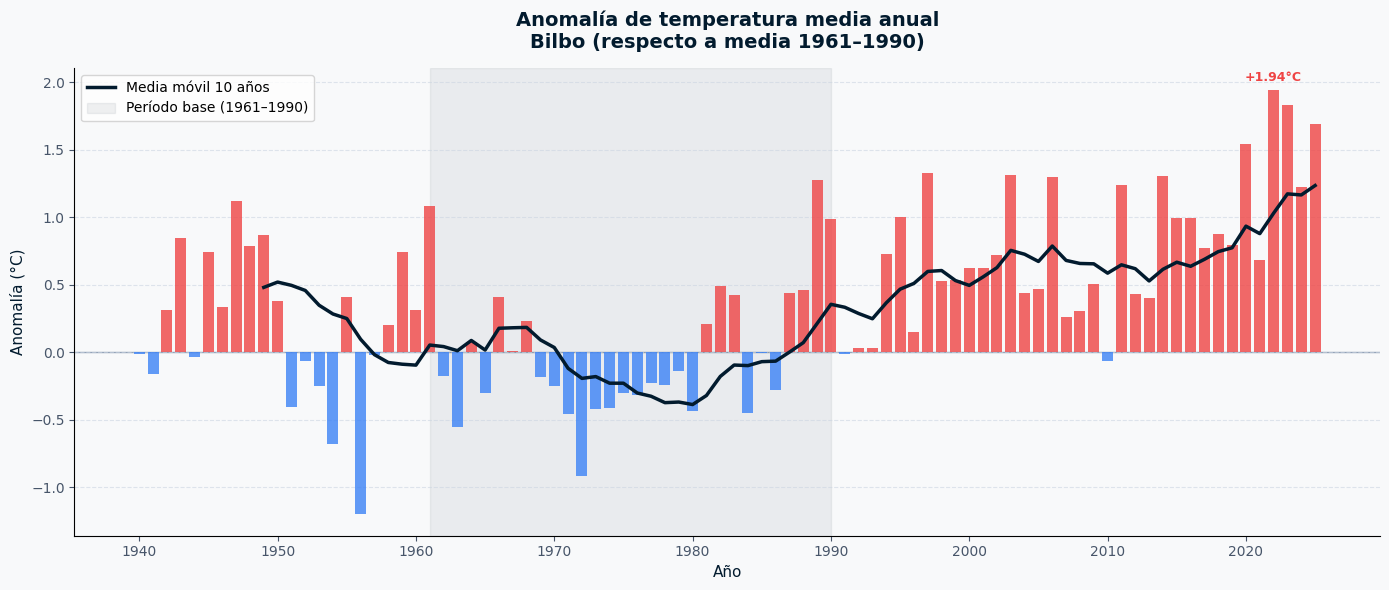

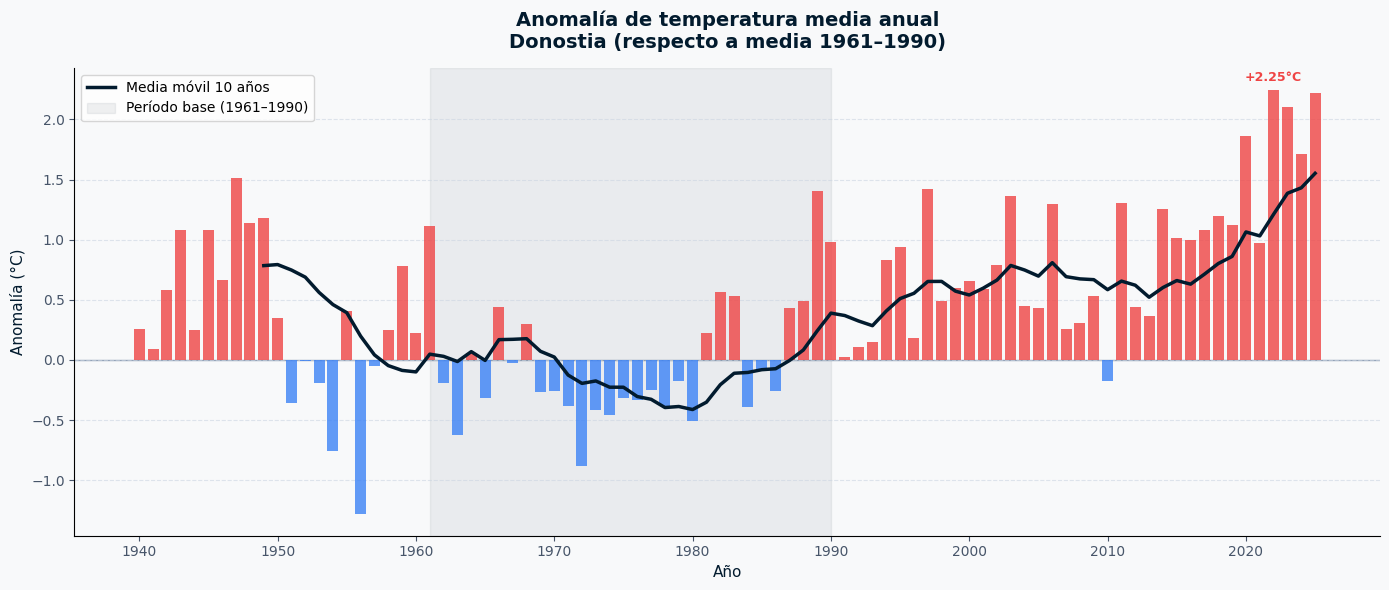

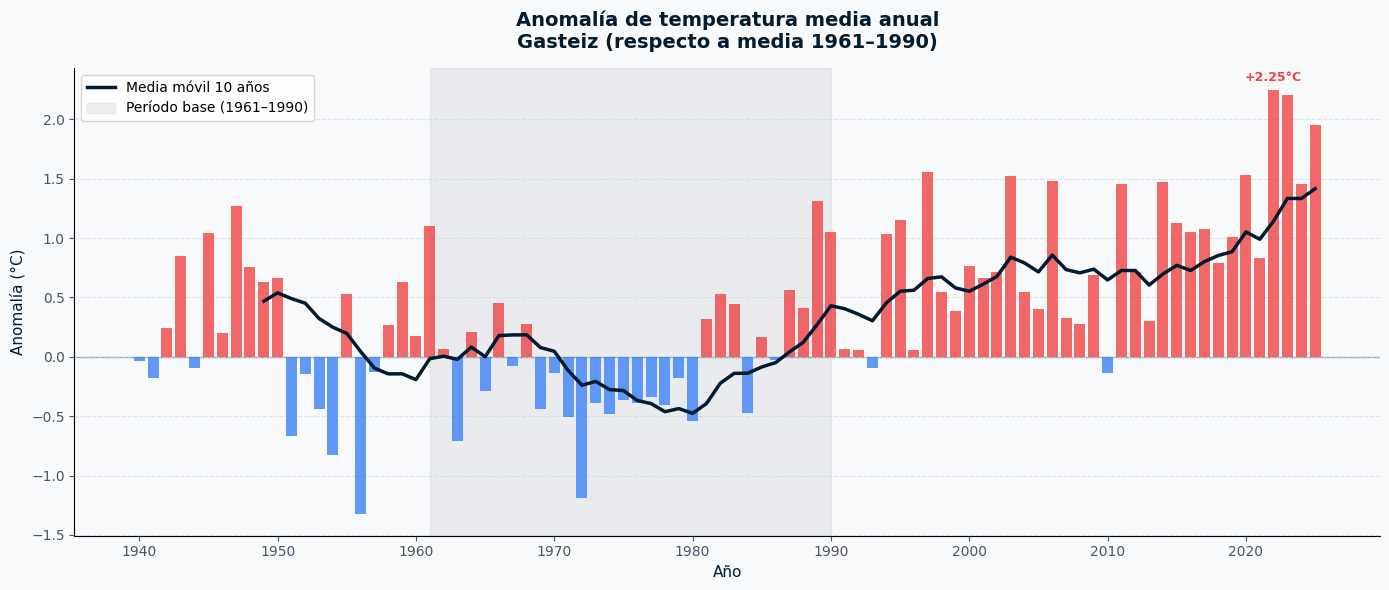

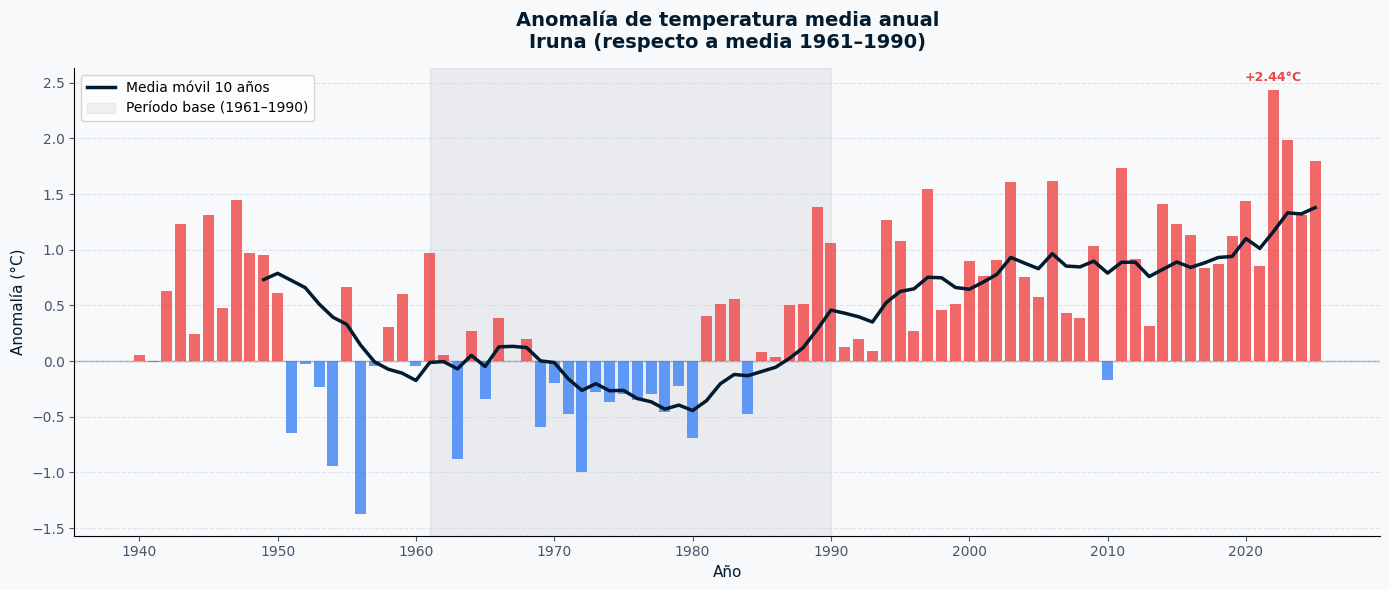

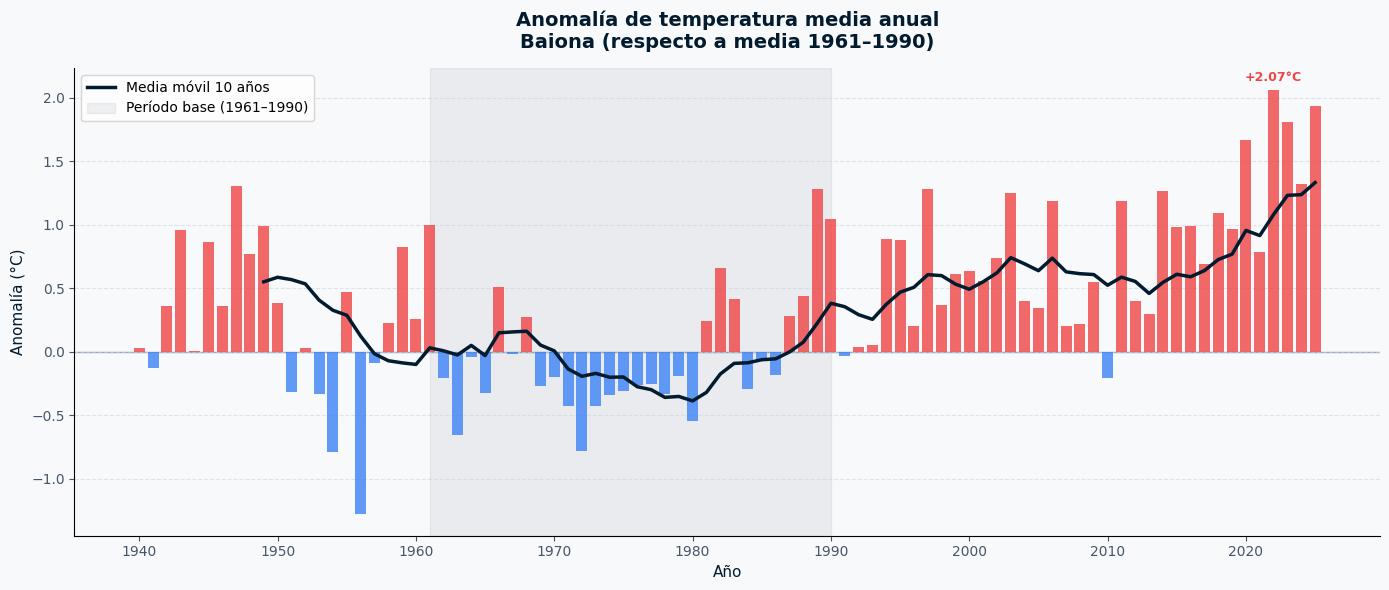

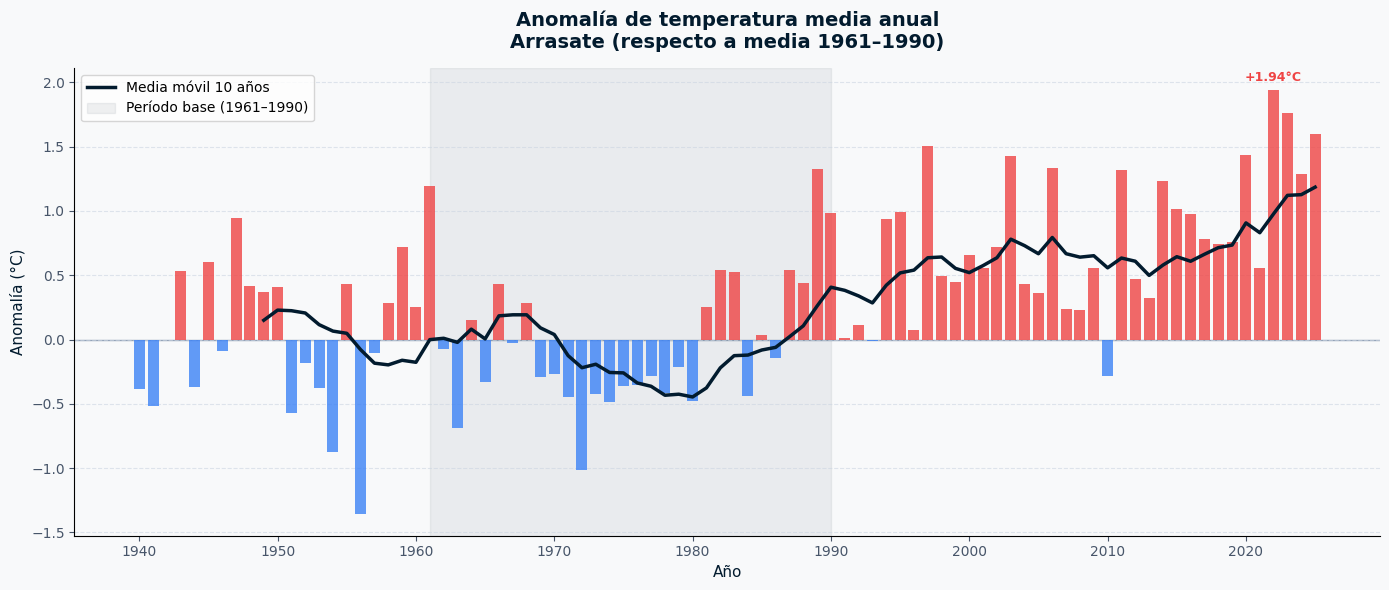

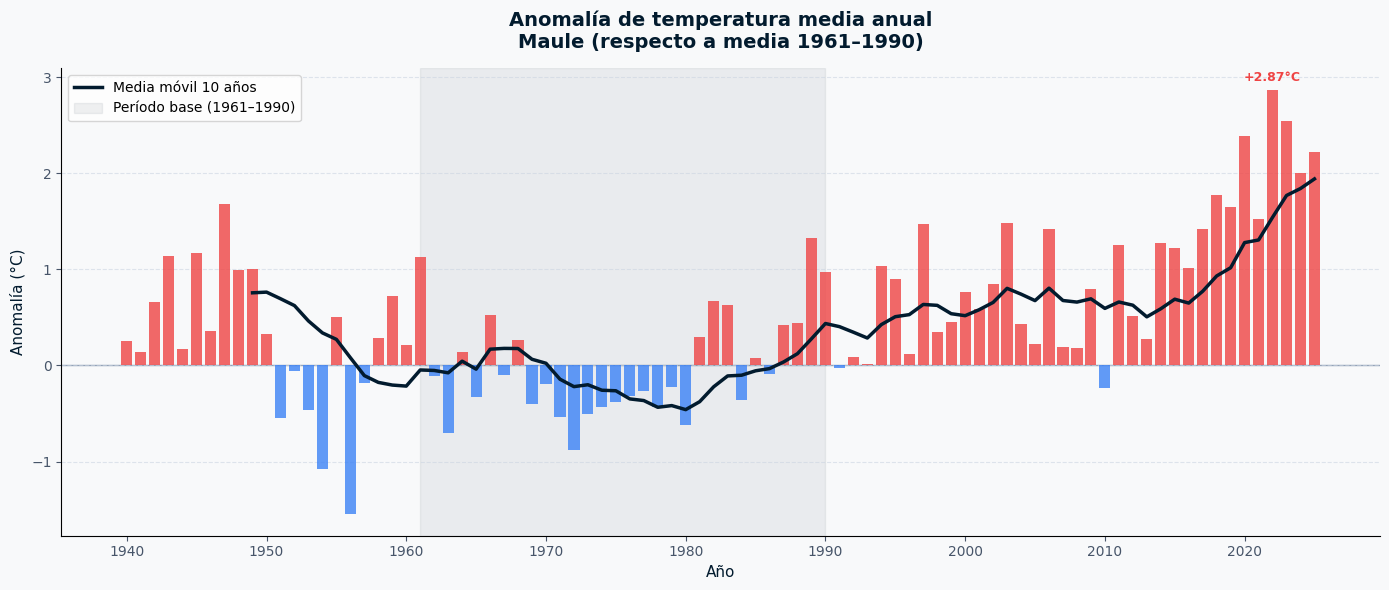

In [7]:
datos_anomalia = anomalia_termica.calcular_todos()
graficos_anomalia.graficar_anomalia(datos_anomalia)

## 6. Comparativa de anomalía entre ciudades

Superponemos las medias móviles de anomalía de todas las ciudades. Si las líneas convergen hacia valores positivos, el calentamiento es generalizado y no localizado.

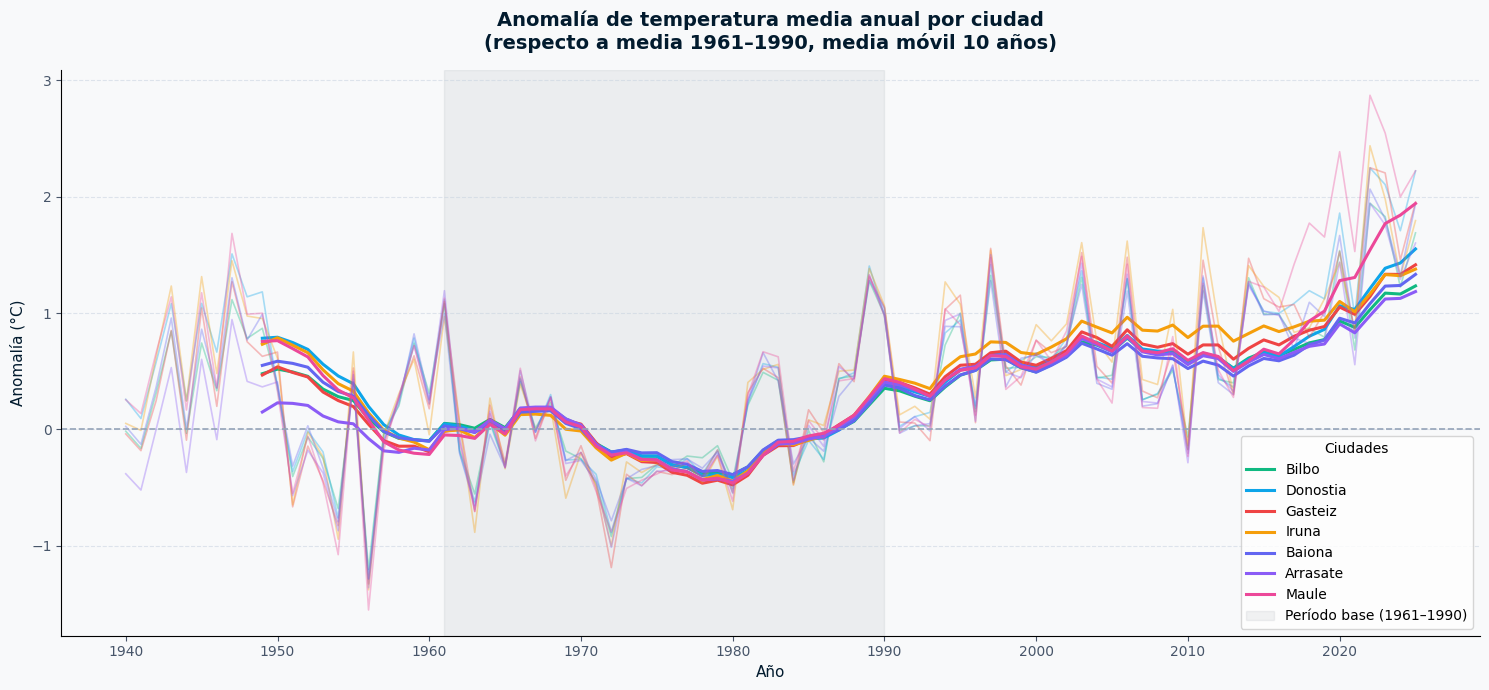

In [8]:
graficos_anomalia.graficar_anomalia_comparativa(datos_anomalia)

## 7. Resumen estadístico

In [9]:
import pandas as pd

rows = []
for r in datos_temp['temp_media']:
    ciudad = r['ciudad']
    slope_decada = r['slope'] * 10
    rows.append({'Ciudad': ciudad.nombre.capitalize(),
                 'Dist. mar (km)': ciudad.dist_mar,
                 'Tendencia (°C/década)': round(slope_decada, 3)})

resumen = pd.DataFrame(rows).sort_values('Tendencia (°C/década)', ascending=False)
display(resumen.style.background_gradient(subset=['Tendencia (°C/década)'], cmap='RdYlBu_r'))

,Ciudad,Dist. mar (km),Tendencia (°C/década)
6,Maule,25.200000,0.172000
2,Gasteiz,58.200000,0.158000
5,Arrasate,33.200000,0.155000
3,Iruna,61.800000,0.148000
1,Donostia,0.000000,0.135000
0,Bilbo,11.100000,0.131000
4,Baiona,1.500000,0.131000
